In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/graphql-sequnce-dataset/val.jsonl
/kaggle/input/graphql-sequnce-dataset/test.jsonl
/kaggle/input/graphql-sequnce-dataset/train.jsonl


In [13]:
import json
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    f1_score,
    confusion_matrix
)
from typing import Dict
import torch.nn.functional as F
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import AutoTokenizer
from transformers import AutoConfig, AutoModel
import matplotlib.pyplot as plt

In [3]:
LABEL_MAP = {
    "normal": 0,
    "malicious": 1,
}

In [4]:
class TextDataset(Dataset):
    """
    Expected JSONL format per row:
    {
        "id": "...",
        "input_text": "...",
        "target_label": "normal" | "malicious",
        "meta": {...}
    }
    """

    def __init__(self, jsonl_path: str, tokenizer, max_len: int = 512):
        self.samples = []
        self.tokenizer = tokenizer
        self.max_len = max_len

        with open(jsonl_path, "r", encoding="utf-8") as f:
            for line in f:
                obj = json.loads(line)

                text = obj["input_text"]
                label = obj["target_label"]

                y = LABEL_MAP[label]
                self.samples.append((text, y))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        text, y = self.samples[idx]

        enc = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt",
        )

        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(y, dtype=torch.float32),
        }

In [5]:
def build_text_dataloaders(
    train_path: str,
    val_path: str,
    tokenizer,
    max_len: int = 512,
    batch_size_train: int = 32,
    batch_size_val: int = 64,
    num_workers: int = 0,
):
    train_ds = TextDataset(train_path, tokenizer, max_len)
    val_ds = TextDataset(val_path, tokenizer, max_len)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size_train,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size_val,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    return train_loader, val_loader

In [6]:
def compute_classification_metrics(y_true: np.ndarray, y_pred_proba: np.ndarray, threshold: float = 0.5) -> Dict[str, float]:
    """
    y_true: shape (N,) values 0/1
    y_pred_proba: shape (N,) probabilities in [0,1]
    """
    y_true = y_true.astype(int)
    y_pred = (y_pred_proba >= threshold).astype(int)

    metrics = {}
    try:
        metrics["accuracy"] = float(accuracy_score(y_true, y_pred))
        metrics["precision"] = float(precision_score(y_true, y_pred, zero_division=0))
        metrics["recall"] = float(recall_score(y_true, y_pred, zero_division=0))
        metrics["f1"] = float(f1_score(y_true, y_pred, zero_division=0))
    except Exception:
        metrics["accuracy"] = metrics["precision"] = metrics["recall"] = metrics["f1"] = 0.0

    try:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_pred_proba))
    except Exception:
        metrics["roc_auc"] = float("nan")

    # FPR at high threshold
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    metrics["fpr"] = float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0
    metrics["tpr"] = float(tp / (tp + fn)) if (tp + fn) > 0 else 0.0

    return metrics


In [7]:
class SOTATransformerClassifier(nn.Module):
    """
    Pretrained Transformer-based binary classifier.

    - Uses a strong encoder (e.g. roberta-base or deberta-v3-base)
    - Adds a small MLP head on top of the pooled representation
    - Outputs logits for BCEWithLogitsLoss

    Forward:
        input_ids: LongTensor (batch, seq_len)
        attention_mask: LongTensor (batch, seq_len) with 1 for tokens, 0 for padding

    Returns:
        logit: FloatTensor (batch,)
    """

    def __init__(
        self,
        model_name: str = "roberta-base",
        dropout: float = 0.2,
        freeze_encoder: bool = False,
    ):
        super().__init__()

        # Load config and backbone
        self.config = AutoConfig.from_pretrained(model_name)
        self.transformer = AutoModel.from_pretrained(model_name, config=self.config)

        hidden_size = self.config.hidden_size

        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1),
        )

        # Optionally freeze encoder (e.g. for ablations / low-resource)
        if freeze_encoder:
            for param in self.transformer.parameters():
                param.requires_grad = False

        self._init_head()

    def _init_head(self):
        # Initialize only the head; encoder stays as loaded
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, input_ids, attention_mask):
        """
        input_ids: (batch, seq_len)
        attention_mask: (batch, seq_len)

        Returns:
            logits: (batch,)
        """
        outputs = self.transformer(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        # For many models:
        # - If pooler_output exists -> use it
        # - Else -> use [CLS] token representation
        if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
            pooled = outputs.pooler_output  # (batch, hidden)
        else:
            # last_hidden_state: (batch, seq_len, hidden)
            pooled = outputs.last_hidden_state[:, 0, :]  # CLS

        logits = self.classifier(pooled).squeeze(-1)
        return logits


In [8]:
# =========================
# Reproducibility
# =========================
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [9]:
# =========================
# Config
# =========================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_NAME = "roberta-base"

SEQ_TRAIN_PATH = "/kaggle/input/graphql-sequnce-dataset/train.jsonl"
SEQ_VAL_PATH   = "/kaggle/input/graphql-sequnce-dataset/val.jsonl"

TOKENIZER_DIR = Path("artifacts/roberta_tokenizer")
MODEL_DIR     = Path("artifacts/roberta_model")

ARTIFACT_PATH = Path("transformer_best.pt")
METRICS_PATH  = Path("transformer_metrics.json")

EPOCHS = 3
LR = 2e-5
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0

MAX_LEN = 256
BATCH_SIZE_TRAIN = 16    # safer for transformers on Kaggle
BATCH_SIZE_VAL   = 32

In [10]:
# ============================================================
# Silence TF / XLA / tokenizer noise (must be first)
# ============================================================
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [11]:
# ============================================================
# Training
# ============================================================
def train():
    print("DEVICE:", DEVICE)

    # --------------------------------------------------------
    # Load tokenizer (local if available, else download once)
    # --------------------------------------------------------
    if TOKENIZER_DIR.exists():
        tokenizer = AutoTokenizer.from_pretrained(
            TOKENIZER_DIR,
            local_files_only=True,
        )
    else:
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        TOKENIZER_DIR.mkdir(parents=True, exist_ok=True)
        tokenizer.save_pretrained(TOKENIZER_DIR)

    # --------------------------------------------------------
    # DataLoaders
    # --------------------------------------------------------
    train_loader, val_loader = build_text_dataloaders(
        SEQ_TRAIN_PATH,
        SEQ_VAL_PATH,
        tokenizer,
        max_len=256,
        batch_size_train=16,
        batch_size_val=32,
        num_workers=2,
    )

    # --------------------------------------------------------
    # Model (local backbone if cached)
    # --------------------------------------------------------
    model = SOTATransformerClassifier(
        model_name=str(MODEL_DIR) if MODEL_DIR.exists() else MODEL_NAME
    ).to(DEVICE)

    if not MODEL_DIR.exists():
        MODEL_DIR.mkdir(parents=True, exist_ok=True)
        model.transformer.save_pretrained(MODEL_DIR)

    # --------------------------------------------------------
    # Optimizer & loss
    # --------------------------------------------------------
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY,
    )

    best_auc = 0.0
    history = []

    # ========================================================
    # Epoch loop
    # ========================================================
    for epoch in range(1, EPOCHS + 1):

        # =========================
        # Train
        # =========================
        model.train()
        epoch_loss = 0.0

        train_pbar = tqdm(
            train_loader,
            desc=f"[TRANSFORMER][Epoch {epoch:02d}] Train",
            leave=False,
        )

        for batch in train_pbar:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].float().to(DEVICE)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

            epoch_loss += loss.item()
            train_pbar.set_postfix(loss=f"{loss.item():.4f}")

        avg_train_loss = epoch_loss / len(train_loader)

        # =========================
        # Validation
        # =========================
        model.eval()
        all_logits, all_labels = [], []

        val_pbar = tqdm(
            val_loader,
            desc=f"[TRANSFORMER][Epoch {epoch:02d}] Val",
            leave=False,
        )

        with torch.no_grad():
            for batch in val_pbar:
                input_ids = batch["input_ids"].to(DEVICE)
                attention_mask = batch["attention_mask"].to(DEVICE)
                labels = batch["labels"].float().to(DEVICE)

                logits = model(input_ids, attention_mask)
                all_logits.append(logits)
                all_labels.append(labels)

        logits = torch.cat(all_logits)
        labels = torch.cat(all_labels)

        probs = torch.sigmoid(logits).cpu().numpy()
        y_true = labels.cpu().numpy()

        metrics = compute_classification_metrics(
            y_true=y_true,
            y_pred_proba=probs,
            threshold=0.5,
        )

        metrics.update({
            "epoch": epoch,
            "train_loss": avg_train_loss,
        })

        history.append(metrics)

        # =========================
        # Checkpoint
        # =========================
        if metrics["roc_auc"] > best_auc:
            best_auc = metrics["roc_auc"]
            ARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), ARTIFACT_PATH)
            saved = True
        else:
            saved = False

        print(
            f"[TRANSFORMER] Epoch {epoch:02d} | "
            f"Loss={avg_train_loss:.4f} | "
            f"AUC={metrics['roc_auc']:.4f} | "
            f"P={metrics['precision']:.4f} | "
            f"R={metrics['recall']:.4f} | "
            f"F1={metrics['f1']:.4f} | "
            f"FPR={metrics['fpr']:.4f} | "
            f"Saved={saved}"
        )

    # ========================================================
    # Save metrics
    # ========================================================
    METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(METRICS_PATH, "w") as f:
        json.dump(history, f, indent=2)

    print(f"Training complete. Best AUC: {best_auc:.4f}")
    print(f"Metrics saved to: {METRICS_PATH}")

In [12]:
print("DEVICE:", DEVICE)
train()

DEVICE: cuda
DEVICE: cuda


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

[TRANSFORMER][Epoch 02] Val:   0%|          | 0/505 [00:00<?, ?it/s]

[TRANSFORMER] Epoch 02 | Loss=0.0599 | AUC=0.9784 | P=1.0000 | R=0.9711 | F1=0.9854 | FPR=0.0000 | Saved=False


[TRANSFORMER][Epoch 03] Train:   0%|          | 0/7058 [00:00<?, ?it/s]

[TRANSFORMER][Epoch 03] Val:   0%|          | 0/505 [00:00<?, ?it/s]

[TRANSFORMER] Epoch 03 | Loss=0.0629 | AUC=0.9836 | P=1.0000 | R=0.9489 | F1=0.9738 | FPR=0.0000 | Saved=False
Training complete. Best AUC: 0.9932
Metrics saved to: transformer_metrics.json


In [14]:
with open("transformer_metrics.json") as f:
    history = json.load(f)

epochs = [m["epoch"] for m in history]
auc = [m["roc_auc"] for m in history]
loss = [m["train_loss"] for m in history]

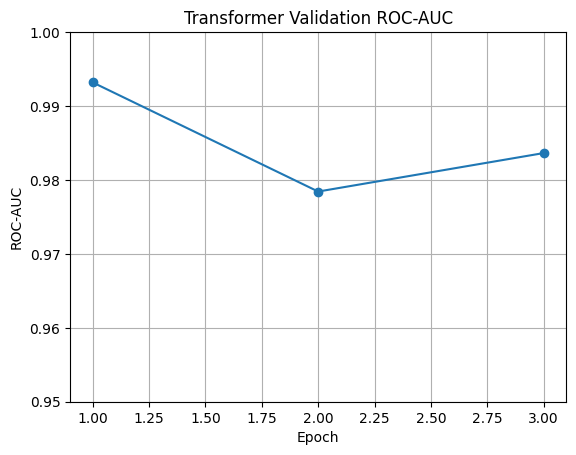

In [21]:
plt.figure()
plt.plot(epochs, auc, marker="o")
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Transformer Validation ROC-AUC")
plt.ylim(0.95, 1.0)
plt.grid(True)
plt.show()

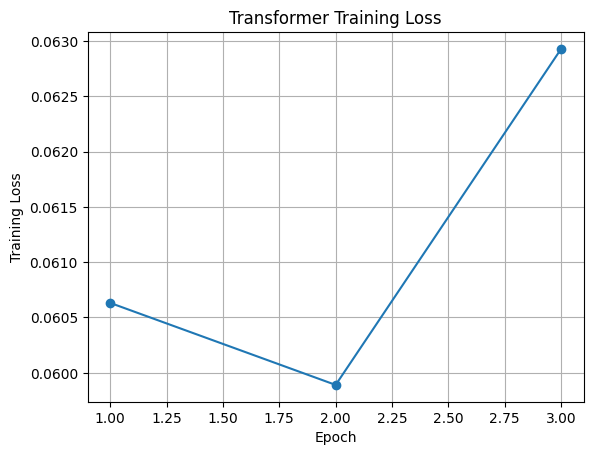

In [23]:
plt.figure()
plt.plot(epochs, loss, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Transformer Training Loss")
plt.grid(True)
plt.show()

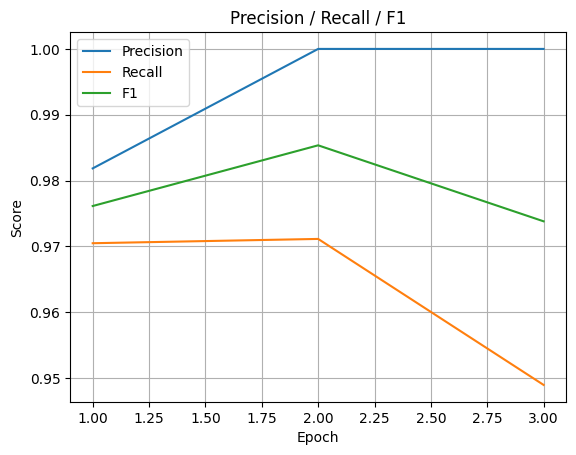

In [20]:
precision = [m["precision"] for m in history]
recall = [m["recall"] for m in history]
f1 = [m["f1"] for m in history]
plt.figure()
plt.plot(epochs, precision, label="Precision")
plt.plot(epochs, recall, label="Recall")
plt.plot(epochs, f1, label="F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Precision / Recall / F1")
plt.legend()
plt.grid(True)
plt.show()

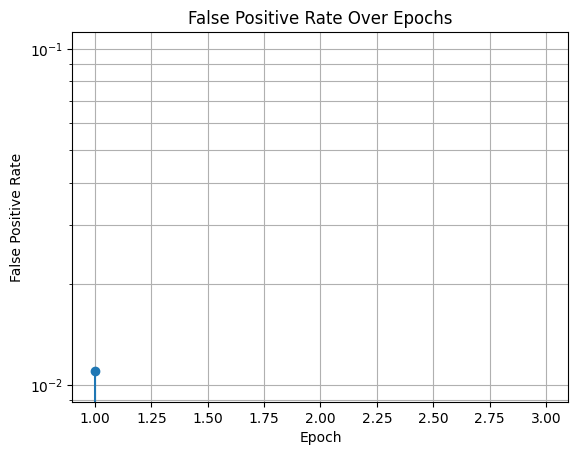

In [24]:
fpr = [m["fpr"] for m in history]

plt.figure()
plt.plot(epochs, fpr, marker="o")
plt.xlabel("Epoch")
plt.ylabel("False Positive Rate")
plt.title("False Positive Rate Over Epochs")
plt.yscale("log")   # IMPORTANT
plt.grid(True, which="both")
plt.show()

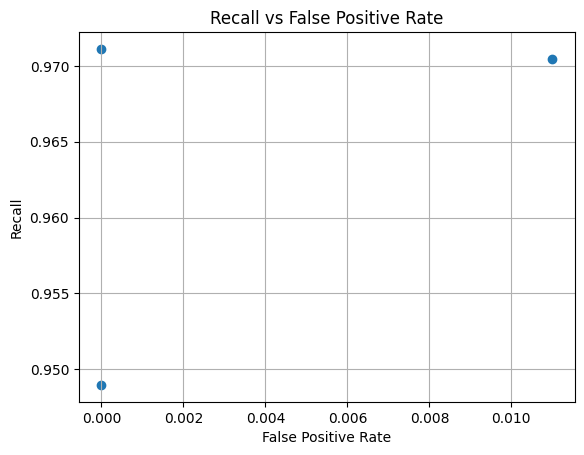

In [25]:
plt.figure()
plt.scatter(fpr, recall)
plt.xlabel("False Positive Rate")
plt.ylabel("Recall")
plt.title("Recall vs False Positive Rate")
plt.grid(True)
plt.show()